In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, exposure
from sklearn.metrics import auc
from src.fractal_analysis.Multifractal import multifractal_analysis, calculate_singularity_spectrum, analyze_multifractality

In [80]:
# import numpy as np
# import matplotlib.pyplot as plt

# from src.crack_segmentation.multifractal import load_image, box_counting_multifractal, analyze_multifractality, plot_multifractal_results

# # IMG_PATH = "./Fractal Database/20241201_090401_color_mask.png"
# # IMG_PATH = "./Fractal Database/101200056.bmp"
# # IMG_PATH = "./test_crop/mask/20241201_090401_crop_3_color_mask.png"
# IMG_PATH = "../Image-based load estimation/Data_Codes/All Images/2meter/12.png"

# image = load_image(IMG_PATH)

# # Perform multifractal analysis
# q_values = np.linspace(-5, 5, 21)  # Range of moments

# print("Performing multifractal analysis...")
# tau_q, D_q, f_alpha, alpha, box_sizes, Z_q = box_counting_multifractal(
#     image, q_values
# )

# # Analyze results
# analyze_multifractality(D_q, alpha, f_alpha)

# # Plot results
# fig = plot_multifractal_results(q_values, tau_q, D_q, f_alpha, alpha, image)
# plt.show()

# print("\nAnalysis complete!")


In [3]:

# IMG_PATH = "./Fractal Database/20241201_090401_color_mask.png"
# IMG_PATH = "./Fractal Database/101200056.bmp"
# IMG_PATH = "./test_crop/mask/20241201_090401_crop_3_color_mask.png"
# IMG_PATH = "../Image-based load estimation/Data_Codes/All Images/2meter/8.png"
# IMG_PATH = "../Image-based load estimation/Data_Codes/All Images/2meter/12.png"
# IMG_PATH = "../Image-based load estimation/Data_Codes/All Images/95Cracks/83.png"
IMG_PATH = "../Image-based load estimation/Data_Codes/All Images/120Cracks/19.png"
# IMG_PATH = "../Image-based load estimation/Data_Codes/All Images/5specimen/2.png"
# IMG_PATH = "../Image-based load estimation/Data_Codes/All Images/Purdu/45.png"

q, dq = multifractal_analysis(IMG_PATH, invert=False)

dq = dq[::-1]

alpha, f_alpha = calculate_singularity_spectrum(q, dq)
mf_properties = analyze_multifractality(q, dq, alpha[::-1], f_alpha[::-1])

print("Is FD == Peak Singularity Spectrum:", mf_properties[4] == max(f_alpha))

Is FD == Peak Singularity Spectrum: True


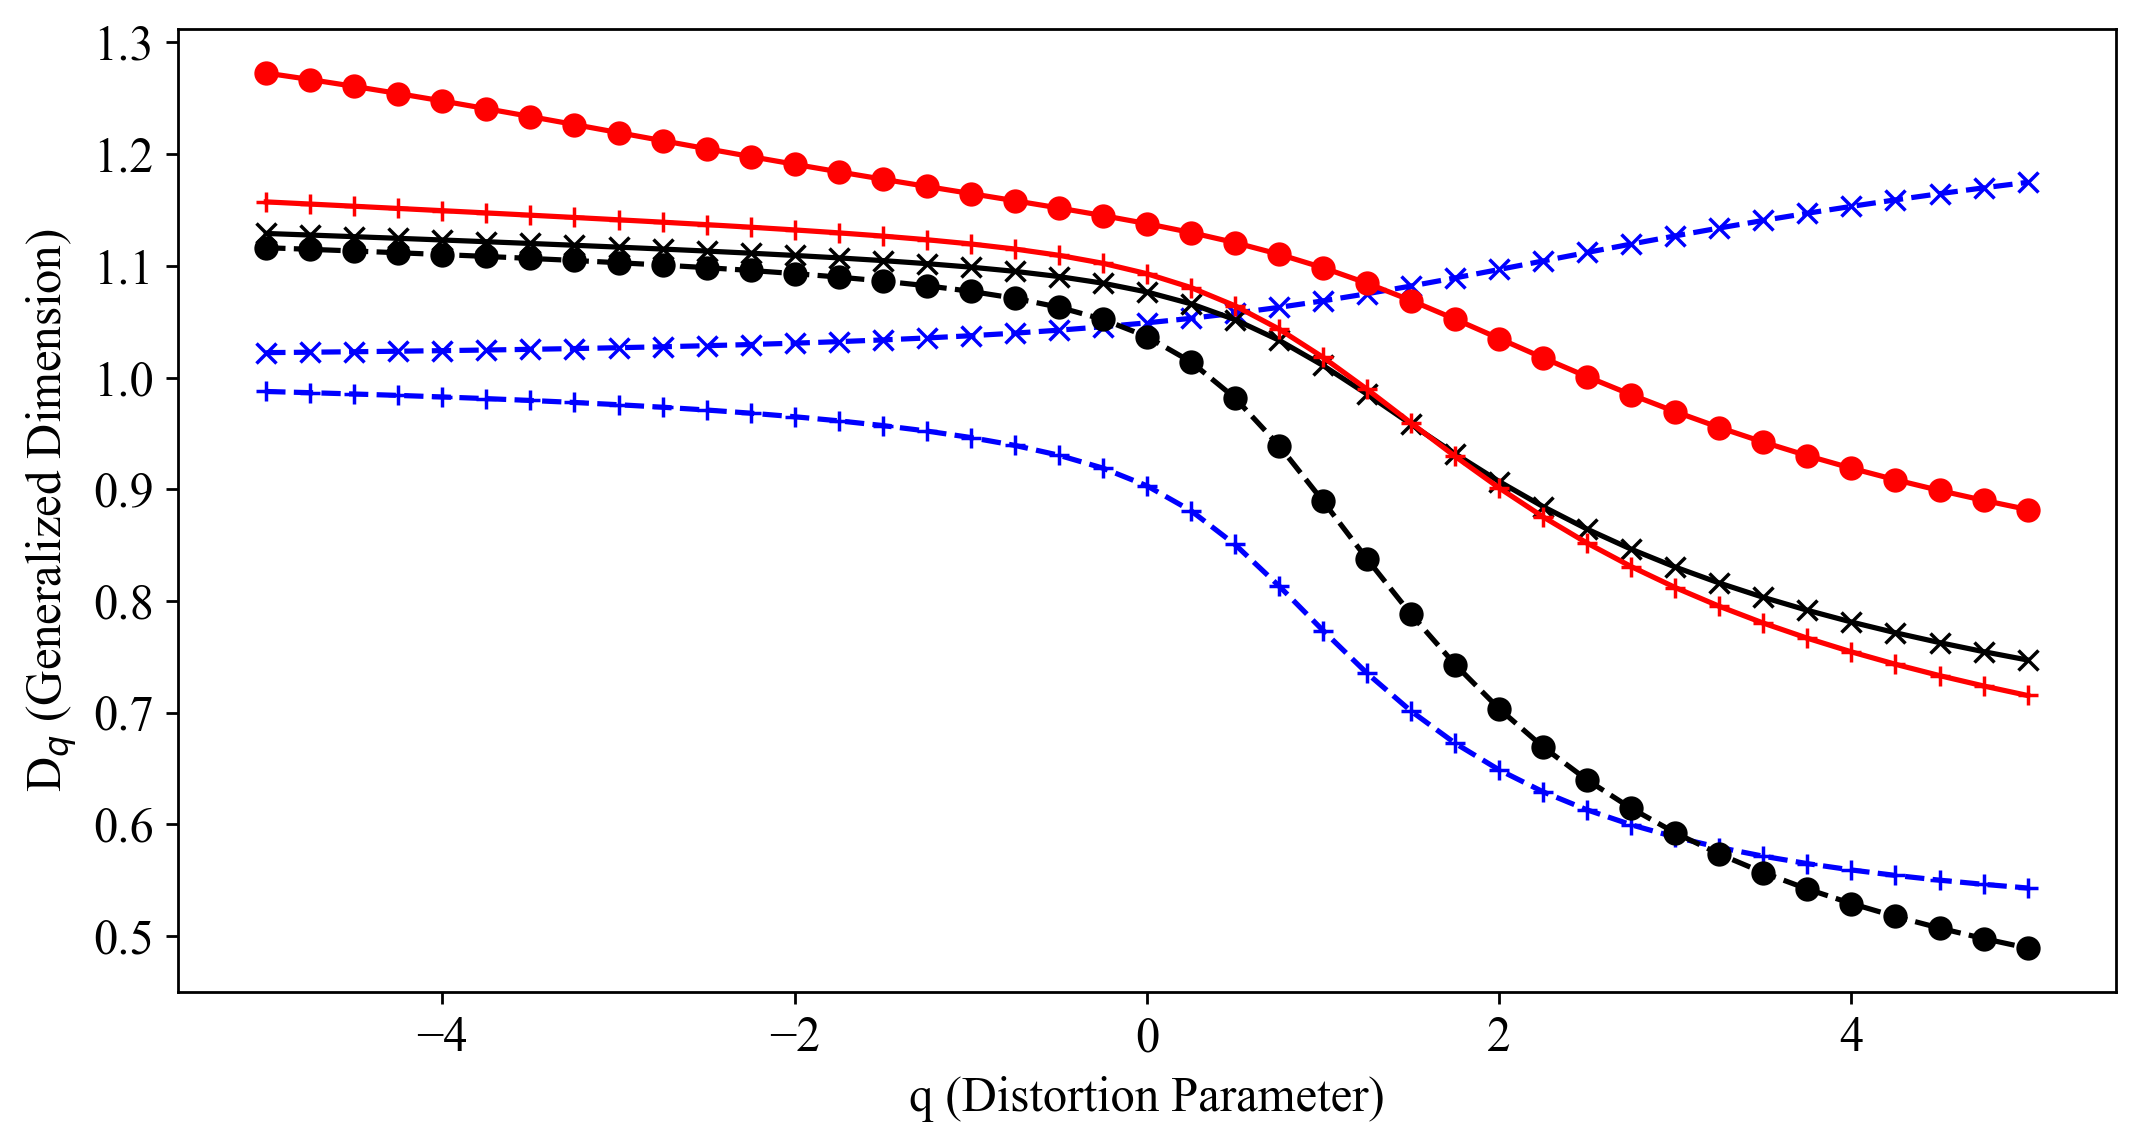

In [16]:
plt.figure(figsize=(10, 5), dpi=250)
plt.rcParams['font.family'] = 'Times New Roman'

color_list = ['blue', 'blue', 'black', 'black', 'red', 'red']
mark_list = ['--x', '--+', '--o', '-x', '-+', '-o']

for i in range(1, 7):
    IMG_PATH = f"../Image-based load estimation/Data_Codes/All Images/5specimen/{i}.png"
    q, dq = multifractal_analysis(IMG_PATH, invert=False)

    dq = dq[::-1]

    alpha, f_alpha = calculate_singularity_spectrum(q, dq)
    mf_properties = analyze_multifractality(q, dq, alpha[::-1], f_alpha[::-1])

    plt.plot(q, dq, mark_list[i-1], c=color_list[i-1], label=f"Image {i}")

plt.xlabel('q (Distortion Parameter)', fontsize=14)
plt.ylabel(r'D$_q$ (Generalized Dimension)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.legend()
plt.show()

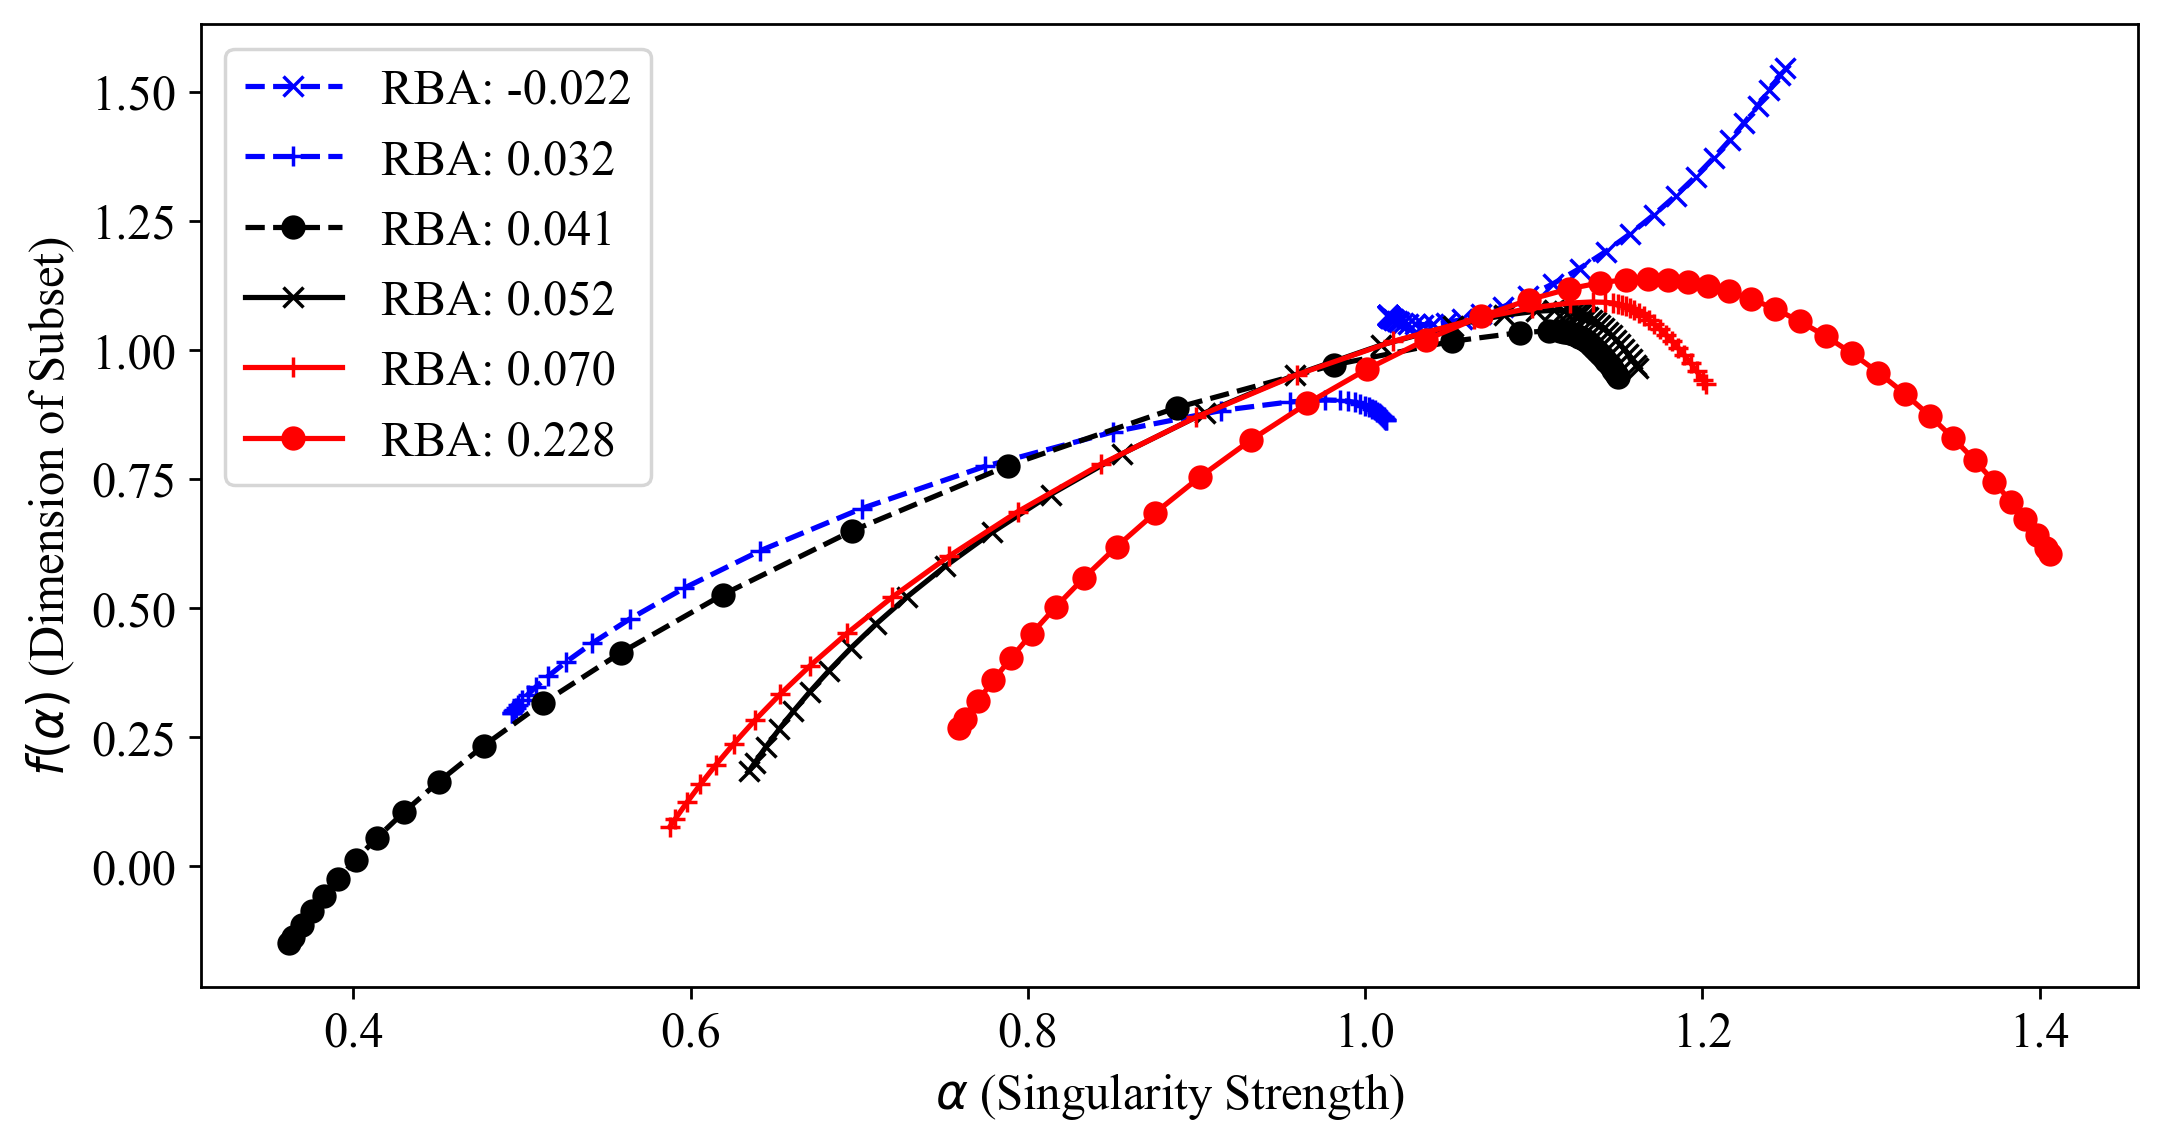

In [17]:
plt.figure(figsize=(10, 5), dpi=250)

color_list = ['blue', 'blue', 'black', 'black', 'red', 'red']
mark_list = ['--x', '--+', '--o', '-x', '-+', '-o']

for i in range(1, 7):
    IMG_PATH = f"../Image-based load estimation/Data_Codes/All Images/5specimen/{i}.png"
    q, dq = multifractal_analysis(IMG_PATH, invert=False)

    dq = dq[::-1]

    alpha, f_alpha = calculate_singularity_spectrum(q, dq)
    mf_properties = analyze_multifractality(q, dq, alpha[::-1], f_alpha[::-1])

    f_a = np.array(f_alpha)

    plt.plot(alpha, f_a, mark_list[i-1], color=color_list[i-1], label=f"RBA: {mf_properties[3]:.3f}")


plt.xlabel('$\\alpha$ (Singularity Strength)', fontsize=14)
plt.ylabel('$f(\\alpha)$ (Dimension of Subset)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.grid(True)
plt.legend(fontsize=14)
plt.show()

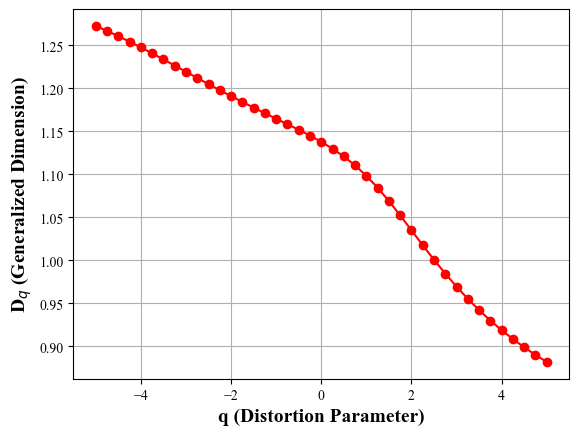

In [20]:
plt.plot(q, dq, 'r-o')
# plt.plot(q, dq[::-1], 'b-x')
plt.xlabel('q (Distortion Parameter)', fontsize=14, weight='bold')
plt.ylabel(r'D$_q$ (Generalized Dimension)', fontsize=14, weight='bold')
plt.grid(True)
plt.show()

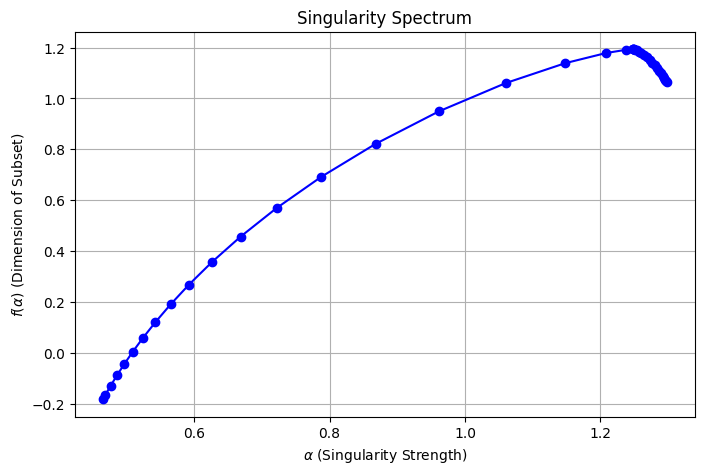

In [4]:
f_a = np.array(f_alpha)

plt.figure(figsize=(8, 5))
plt.plot(alpha, f_a, 'b-o')
plt.xlabel(r'$\alpha$ (Singularity Strength)')
plt.ylabel(r'$f(\alpha)$ (Dimension of Subset)')
plt.title('Singularity Spectrum')
plt.grid(True)
plt.show()